In [ ]:
!pip install git+https://github.com/ScaleAGData/scaleag-vito.git@prometheo-integration --quiet
!pip install tabulate --quiet

In [ ]:
from pathlib import Path
from scaleagdata_vito.openeo.extraction_utils import (
    check_job_status,
    get_succeeded_job_details,
    load_point_extractions,
    get_band_statistics,
    visualize_timeseries,
)
import geopandas as gpd
from loguru import logger

#### Assess data correctness before launching the OpenEO jobs 
You can run some checks on your input file to make sure they are suitable to run the extractions successfully. In particular, it is important to check the validity of the geometries and, ideally, to also have a column containing a unique id for each sample.

In case of invalid geometries, you will be provided with both the dataframe with the failing polygons to be fixed and the one with valid geometries.

In [ ]:
def check_unique_id(df_path, unique_id):
    df = gpd.read_file(df_path)
    if df[unique_id].nunique() != df.shape[0]:
        logger.info("IDs are not unique!")
        return df[df[unique_id].duplicated(keep=False)]
    else:
        logger.info("IDs are unique")
        return None

def check_valid_geometry(df):
    if isinstance(df, str):
        df = gpd.read_file(df)
    df_invalid = df[~df.geometry.is_valid]
    # Assessing wheather some invalid geometries are present
    if len(df_invalid) > 0:
        # 1) some invalid geometries are present. Attempt fixing them
        df['geometry'] = df.geometry.buffer(0)
        df_invalid = df[~df.geometry.is_valid]
        df_valid = df[df.geometry.is_valid]
        if len(df_invalid) > 0:
            # 2) Still some invalid geometries are present. Return them
            logger.info("Invalid geometries found! Returning invalid geometries")
            return df_invalid, df_valid
        else:
            # All geometries are now valid. Return fixed dataframe and empty dataframe for invalid geometries
            logger.info("Fixed some invalid geometries. All geometries are now valid")
            return gpd.GeoDataFrame(), df
    else:
        # All geometries are valid. Return empty dataframe for invalid geometries
        logger.info("All geometries are valid")
        return gpd.GeoDataFrame(), df

In [ ]:
input_file = ".../extraction_inputfile.geojson"
invalid_geom, valid_geom = check_valid_geometry(input_file)
non_unique_ids = check_unique_id(input_file, unique_id="Field_id")

2025-08-11 14:16:22.431 | INFO     | __main__:check_valid_geometry:30 - All geometries are valid
2025-08-11 14:16:22.459 | INFO     | __main__:check_unique_id:7 - IDs are unique


### Inspect OpenEO extractions

Once the extractions have been completed, we can inspect the job tracking dataframe to find out how many jobs were successfully completed.


In [ ]:
extraction_folder = Path("/path/to/extractions/")  # Replace with your output folder path
status_histogram = check_job_status(extraction_folder)
succeeded_jobs = get_succeeded_job_details(extraction_folder)

+----------+---------+
| status   |   count |
|----------+---------|
| finished |       3 |
+----------+---------+
+------------------------------------+-----------+-------------+-----------------+
| id                                 | s2_tile   |   n_samples |   duration_mins |
|------------------------------------+-----------+-------------+-----------------|
| j-25080808194749b6a107246360664629 | 30PYR     |          45 |         8.21667 |
| j-2508080836114d1784aefece0aa2d864 | 30PYR     |          43 |         5.13333 |
| j-2508080844014d98b06c4a34d2b70eac | 30PYR     |          40 |         6.28333 |
+------------------------------------+-----------+-------------+-----------------+


We can do a more in-depth check of the extracted data by:

- manually inspecting a subset of the extracted data (`load_point_extractions` function)

- printing statistics for each individual band that was extracted (`get_band_statistics` function)

- visualizing time series for a specified sample id (`visualize_timeseries` function)

NOTE: keep in mind when inspecting the results that nodata value = 0

In [3]:
gdf = load_point_extractions(
    extractions_dir=Path(extraction_folder),
    subset=False,
)
stats_df = get_band_statistics(gdf)

2025-08-08 17:05:12.946 | INFO     | scaleagdata_vito.openeo.extraction_utils:load_point_extractions:166 - Found 3 geoparquet files in /home/giorgia/Private/data/geomaize/new_extractions


+---------------+------------+--------+--------+--------+-------+---------------+------------+
| band          |   %_nodata |    min |    max |   mean |   std | start_datae   | end_date   |
|---------------+------------+--------+--------+--------+-------+---------------+------------|
| S2-L2A-B02    |      38.48 |   0    |   0.26 |   0.08 |  0.02 | 2021-01-01    | 2023-12-31 |
| S2-L2A-B03    |      38.48 |   0.03 |   0.28 |   0.11 |  0.03 | 2021-01-01    | 2023-12-31 |
| S2-L2A-B04    |      38.48 |   0.02 |   0.32 |   0.15 |  0.05 | 2021-01-01    | 2023-12-31 |
| S2-L2A-B05    |      38.48 |   0.07 |   0.36 |   0.2  |  0.04 | 2021-01-01    | 2023-12-31 |
| S2-L2A-B06    |      38.48 |   0.08 |   0.41 |   0.25 |  0.04 | 2021-01-01    | 2023-12-31 |
| S2-L2A-B07    |      38.48 |   0.09 |   0.47 |   0.27 |  0.05 | 2021-01-01    | 2023-12-31 |
| S2-L2A-B08    |      38.48 |   0.09 |   0.46 |   0.27 |  0.05 | 2021-01-01    | 2023-12-31 |
| S2-L2A-B8A    |      38.48 |   0.1  |   0.5  |  

In [4]:
gdf.sample_id.unique()

array(['5012LAB', '5057PAG', '7016SAM', '7068ZIN', '7074ZIN', '1056ZIN',
       '3074TAM', '5033TUG', '7015SAM', '7016ALH', '7036FUU', '7036SAN',
       '7061CHE', '7062CHE', '7070ZIN', '7071ZIN', '7072ZIN', '1055ZIN',
       '1029ZIN', '1061ZIN', '1067ZIN', '2002ALH', '2050KPA', '2053KPA',
       '3075TAM', '4020FUU', '5002LAB', '5011LAB', '5014LAB', '5016ZOR',
       '5017ZOR', '5034TUG', '5036TUG', '5037TUG', '7014SAM', '7015ALH',
       '7017SAM', '7018ALH', '7019ZOR', '7022FUU', '7033FUU', '7035FUU',
       '7058CHE', '7059CHE', '7069ZIN', '3089TIN', '3084TIN', '3062FUU',
       '1061zin', '3030Tin', '3073lab', '5036tug', '5060tug', '5002lab',
       '5014lab', '3074lab', '5012lab', '3075lab', '3076lab', '3077tug',
       '3078kpa', '3077kpa', '2050kpa', '3088TIN', '3087TIN', '3086TIN',
       '3085TIN', '3083TIN', '3082TIN', '3081TIN', '3080TIN', '3072ZIN',
       '3071ZIN', '3070ZIN', '3069TIN', '3068TIN', '3067FUU', '3066FUU',
       '3065FUU', '3064FUU', '3063FUU', '5038PAG', 

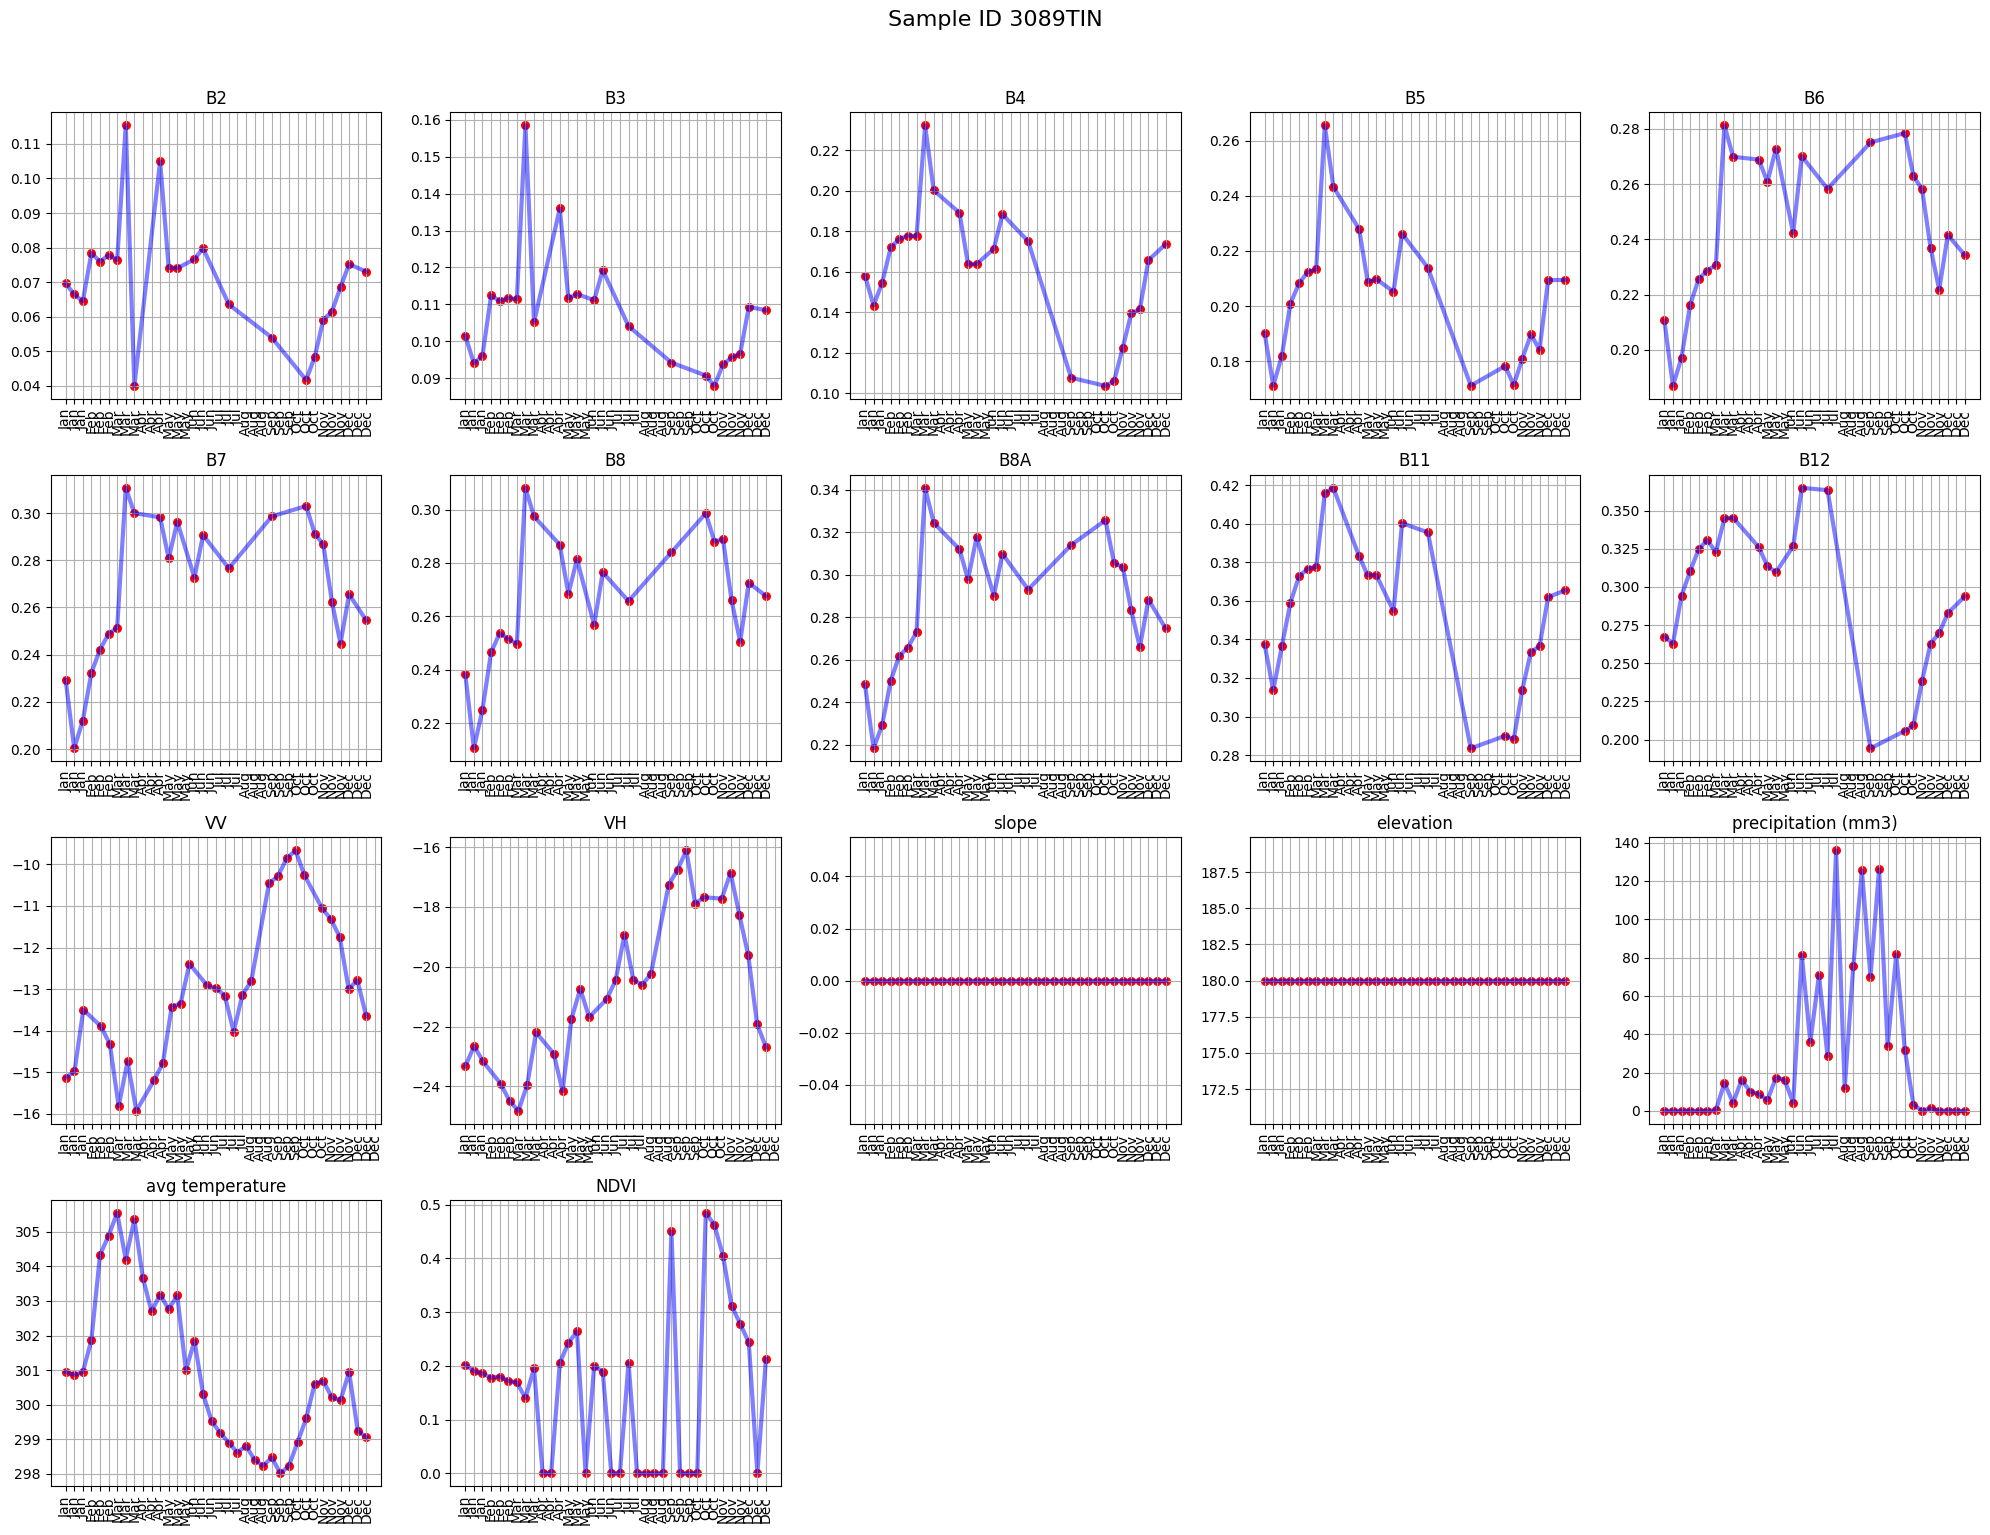

In [5]:
visualize_timeseries(gdf, sample_id="3089TIN")